In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys, os

sys.path.append('../src/')
sys.path.append('../content/')

import data_utils as du
import numpy as np
from functools import reduce
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import haversine_distances

### DEFINE UTILITIES ###

# Calculate task-agnostic overlap between embeddings
# This basically compares feature similarity structure across examples
# It's based on https://arxiv.org/pdf/1905.00414 and the accompanying demo
# https://colab.research.google.com/github/google-research/google-research/blob/master/representation_similarity/Demo.ipynb
# For now I'll just copy over their utility functions

import numpy as np


def gram_linear(x):
  """Compute Gram (kernel) matrix for a linear kernel.

  Args:
    x: A num_examples x num_features matrix of features.

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  return x.dot(x.T)


def gram_rbf(x, threshold=1.0):
  """Compute Gram (kernel) matrix for an RBF kernel.

  Args:
    x: A num_examples x num_features matrix of features.
    threshold: Fraction of median Euclidean distance to use as RBF kernel
      bandwidth. (This is the heuristic we use in the paper. There are other
      possible ways to set the bandwidth; we didn't try them.)

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  dot_products = x.dot(x.T)
  sq_norms = np.diag(dot_products)
  sq_distances = -2 * dot_products + sq_norms[:, None] + sq_norms[None, :]
  sq_median_distance = np.median(sq_distances)
  return np.exp(-sq_distances / (2 * threshold ** 2 * sq_median_distance))


def center_gram(gram, unbiased=False):
  """Center a symmetric Gram matrix.

  This is equvialent to centering the (possibly infinite-dimensional) features
  induced by the kernel before computing the Gram matrix.

  Args:
    gram: A num_examples x num_examples symmetric matrix.
    unbiased: Whether to adjust the Gram matrix in order to compute an unbiased
      estimate of HSIC. Note that this estimator may be negative.

  Returns:
    A symmetric matrix with centered columns and rows.
  """
  if not np.allclose(gram, gram.T):
    raise ValueError('Input must be a symmetric matrix.')
  gram = gram.copy()

  if unbiased:
    # This formulation of the U-statistic, from Szekely, G. J., & Rizzo, M.
    # L. (2014). Partial distance correlation with methods for dissimilarities.
    # The Annals of Statistics, 42(6), 2382-2412, seems to be more numerically
    # stable than the alternative from Song et al. (2007).
    n = gram.shape[0]
    np.fill_diagonal(gram, 0)
    means = np.sum(gram, 0, dtype=np.float64) / (n - 2)
    means -= np.sum(means) / (2 * (n - 1))
    gram -= means[:, None]
    gram -= means[None, :]
    np.fill_diagonal(gram, 0)
  else:
    means = np.mean(gram, 0, dtype=np.float64)
    means -= np.mean(means) / 2
    gram -= means[:, None]
    gram -= means[None, :]

  return gram


def cka(gram_x, gram_y, debiased=False):
  """Compute CKA.

  Args:
    gram_x: A num_examples x num_examples Gram matrix.
    gram_y: A num_examples x num_examples Gram matrix.
    debiased: Use unbiased estimator of HSIC. CKA may still be biased.

  Returns:
    The value of CKA between X and Y.
  """
  gram_x = center_gram(gram_x, unbiased=debiased)
  gram_y = center_gram(gram_y, unbiased=debiased)

  # Note: To obtain HSIC, this should be divided by (n-1)**2 (biased variant) or
  # n*(n-3) (unbiased variant), but this cancels for CKA.
  scaled_hsic = gram_x.ravel().dot(gram_y.ravel())

  normalization_x = np.linalg.norm(gram_x)
  normalization_y = np.linalg.norm(gram_y)
  return scaled_hsic / (normalization_x * normalization_y)


def _debiased_dot_product_similarity_helper(
        xty, sum_squared_rows_x, sum_squared_rows_y, squared_norm_x, squared_norm_y,
        n):
  """Helper for computing debiased dot product similarity (i.e. linear HSIC)."""
  # This formula can be derived by manipulating the unbiased estimator from
  # Song et al. (2007).
  return (
      xty - n / (n - 2.) * sum_squared_rows_x.dot(sum_squared_rows_y)
      + squared_norm_x * squared_norm_y / ((n - 1) * (n - 2)))


def feature_space_linear_cka(features_x, features_y, debiased=False):
  """Compute CKA with a linear kernel, in feature space.

  This is typically faster than computing the Gram matrix when there are fewer
  features than examples.

  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.
    debiased: Use unbiased estimator of dot product similarity. CKA may still be
      biased. Note that this estimator may be negative.

  Returns:
    The value of CKA between X and Y.
  """
  features_x = features_x - np.mean(features_x, 0, keepdims=True)
  features_y = features_y - np.mean(features_y, 0, keepdims=True)

  dot_product_similarity = np.linalg.norm(features_x.T.dot(features_y)) ** 2
  normalization_x = np.linalg.norm(features_x.T.dot(features_x))
  normalization_y = np.linalg.norm(features_y.T.dot(features_y))

  if debiased:
    n = features_x.shape[0]
    # Equivalent to np.sum(features_x ** 2, 1) but avoids an intermediate array.
    sum_squared_rows_x = np.einsum('ij,ij->i', features_x, features_x)
    sum_squared_rows_y = np.einsum('ij,ij->i', features_y, features_y)
    squared_norm_x = np.sum(sum_squared_rows_x)
    squared_norm_y = np.sum(sum_squared_rows_y)

    dot_product_similarity = _debiased_dot_product_similarity_helper(
        dot_product_similarity, sum_squared_rows_x, sum_squared_rows_y,
        squared_norm_x, squared_norm_y, n)
    normalization_x = np.sqrt(_debiased_dot_product_similarity_helper(
        normalization_x ** 2, sum_squared_rows_x, sum_squared_rows_x,
        squared_norm_x, squared_norm_x, n))
    normalization_y = np.sqrt(_debiased_dot_product_similarity_helper(
        normalization_y ** 2, sum_squared_rows_y, sum_squared_rows_y,
        squared_norm_y, squared_norm_y, n))

  return dot_product_similarity / (normalization_x * normalization_y)

def cca(features_x, features_y):
  """Compute the mean squared CCA correlation (R^2_{CCA}).

  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.

  Returns:
    The mean squared CCA correlations between X and Y.
  """
  qx, _ = np.linalg.qr(features_x)  # Or use SVD with full_matrices=False.
  qy, _ = np.linalg.qr(features_y)
  return np.linalg.norm(qx.T.dot(qy)) ** 2 / min(
      features_x.shape[1], features_y.shape[1])

def rsa(features_x, features_y):
   """Only function that's not taken from Kornblith et al.
  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.

  Returns:
    The similarity-of-similarities, i.e. the correlation between
    the upper triangles of the example x example correlation matrices
    for the both sets of features

   """
   cx = np.corrcoef(features_x)
   cy = np.corrcoef(features_y)
   upper_triangles = np.stack([m[np.triu_indices(features_x.shape[0],1)] for m in [cx, cy]])
   return np.corrcoef(upper_triangles[:, np.sum(np.isnan(upper_triangles),axis=0)==0])[0,1]

### LOAD DATA ###

In [4]:
def cca_weighted(features_x, features_y):
    qx, _ = np.linalg.qr(features_x)
    qy, _ = np.linalg.qr(features_y)
    
    cross = qx.T.dot(qy)
    _, singular_values, _ = np.linalg.svd(cross, full_matrices=False)
    
    correlations = singular_values ** 2          # R² for each CC pair
    weights = correlations / correlations.sum()  # variance-proportional weights
    
    return np.sum(weights * correlations)        # weighted mean R²


In [5]:

### LOAD DATA ###

# Initialise paths
# data_folder = '/Users/jbakermans/Documents/Data/Thijs'
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'
list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

# Set data sources for which I have pixel values
modalities = ['alphaearth', 'tessera', 'satclip', 'geoclip'] 
samples = ['random_sample', 'lc_stratified_sample']
sample_ids = [gdf_points['id'][gdf_points[s]==1].to_numpy() for s in samples]
embeddings = [[du.load_csv_with_points(parent_folder=data_folder, modality=m, sample_type=s) 
               for s in samples] for m in modalities]

# Only included samples that are present across all modalities
common_samples = [[e['id'].to_numpy() for e in emb] for emb in embeddings]
common_samples = [reduce(np.intersect1d, ([s[i] for s in common_samples])) for i in range(len(samples))]
common_embeddings = [[e.set_index("id").loc[inc].reset_index(drop=True).to_numpy() for inc, e in zip(common_samples, emb)] for emb in embeddings]

### CALCULATE OVERLAP ###
# Choose which sample to plot for (s=0: random; s=1: stratified)
s = 0
sim_cka = np.zeros((len(modalities), len(modalities)))
sim_cca = np.zeros((len(modalities), len(modalities)))
sim_rsa = np.zeros((len(modalities), len(modalities)))
sim_cca_weighted = np.zeros((len(modalities), len(modalities)))

# Bit dumb to calculate all entries of symmetric matrices but whatever
for i, e_from in enumerate(common_embeddings):
    for j, e_to in enumerate(common_embeddings):
        sim_cka[i, j] = feature_space_linear_cka(e_from[s], e_to[s])
        sim_cca[i, j] = cca(e_from[s], e_to[s])
        sim_rsa[i, j] = rsa(e_from[s], e_to[s])
        sim_cca_weighted[i, j] = cca_weighted(e_from[s], e_to[s])
        print(f'Finished {i}, {j}')


Sample random_sample has 9995 data points out of 18965.
Sample lc_stratified_sample has 9997 data points out of 18965.
Number of samples: 18965
Finished 0, 0


/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Finished 0, 1
Finished 0, 2
Finished 0, 3
Finished 1, 0
Finished 1, 1
Finished 1, 2
Finished 1, 3
Finished 2, 0
Finished 2, 1
Finished 2, 2
Finished 2, 3
Finished 3, 0
Finished 3, 1
Finished 3, 2
Finished 3, 3


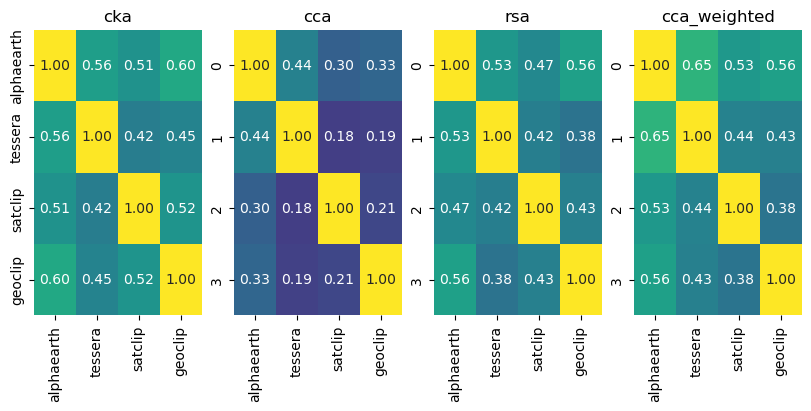

In [12]:
import seaborn as sns
# Plot results
fig, axs = plt.subplots(1, 4, figsize=(8, 4), constrained_layout=True)
ims = []
for col, (ax, data, method) in enumerate(zip(
    axs,
    [sim_cka, sim_cca, sim_rsa, sim_cca_weighted],
    ['cka', 'cca', 'rsa', 'cca_weighted']
)):
    # im = ax.imshow(data, vmin=0, vmax=1)
    sns.heatmap(data, vmin=0, vmax=1, annot=True, fmt=".2f", cmap='viridis', ax=ax, cbar=False)
    # ims.append(im)
    ax.set_title(method)
    ax.set_xticks(np.arange(4) + 0.5)
    ax.set_xticklabels(modalities, rotation=90)
    if col == 0:
        ax.set_yticks(np.arange(4) + 0.5)
        ax.set_yticklabels(modalities)
# fig.colorbar(ims[0], ax=axs, location='right', shrink=0.5)

In [13]:
dict_data = {x: [] for x in ['pair', 'cka', 'cca', 'rsa', 'cca_weighted']}
for i in range(len(modalities)):
    for j in range(i+1, len(modalities)):
        dict_data['pair'].append(f'{modalities[i]}-{modalities[j]}')
        dict_data['cka'].append(sim_cka[i, j])
        dict_data['cca'].append(sim_cca[i, j])
        dict_data['rsa'].append(sim_rsa[i, j])
        dict_data['cca_weighted'].append(sim_cca_weighted[i, j])

import pandas as pd
df_results = pd.DataFrame(dict_data)
df_results.to_csv('../outputs/task_agnostic_overlap.csv', index=False)

Finished region 0 / 8901


/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Finished region 100 / 8901
Finished region 200 / 8901
Finished region 300 / 8901
Finished region 400 / 8901
Finished region 500 / 8901
Finished region 600 / 8901
Finished region 700 / 8901
Finished region 800 / 8901
Finished region 900 / 8901
Finished region 1000 / 8901
Finished region 1100 / 8901
Finished region 1200 / 8901
Finished region 1300 / 8901
Finished region 1400 / 8901
Finished region 1500 / 8901
Finished region 1600 / 8901
Finished region 1700 / 8901
Finished region 1800 / 8901
Finished region 1900 / 8901
Finished region 2000 / 8901
Finished region 2100 / 8901
Finished region 2200 / 8901
Finished region 2300 / 8901
Finished region 2400 / 8901
Finished region 2500 / 8901
Finished region 2600 / 8901
Finished region 2700 / 8901
Finished region 2800 / 8901
Finished region 2900 / 8901
Finished region 3000 / 8901
Finished region 3100 / 8901
Finished region 3200 / 8901
Finished region 3300 / 8901
Finished region 3400 / 8901
Finished region 3500 / 8901
Finished region 3600 / 8901
F

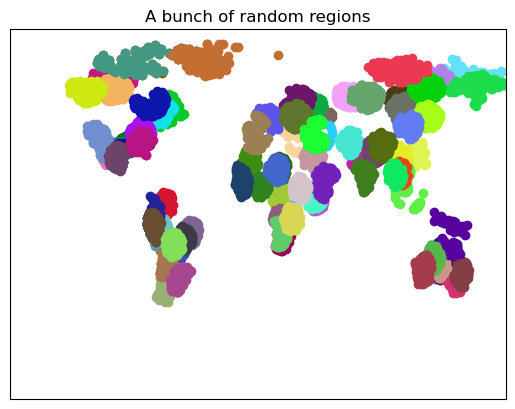

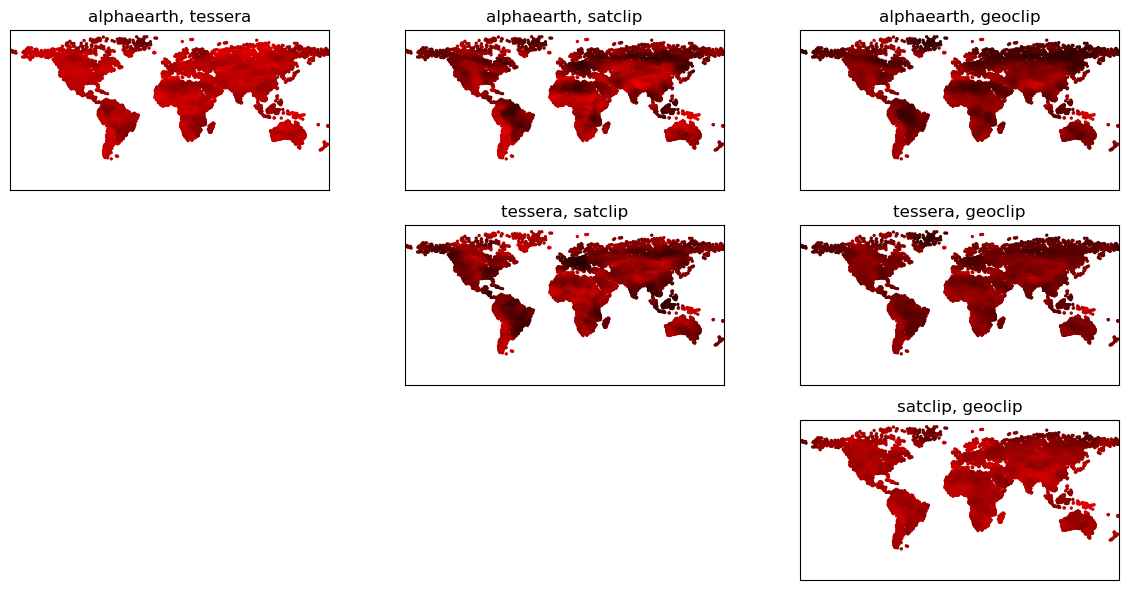

In [ ]:

### CREATE OVERLAP MAPS ###

# Show representational overlap localised around patches:
# compute across a region of nearest neighbours for each patch
# Get longitude and latitude for all patches
locs = [gdf_points.set_index("id").loc[samp].reset_index(drop=True)[['lat', 'lon']].to_numpy() for samp in common_samples]
loc = locs[s]

# Create a approximate distance matrix between all points
# This is inaccurate but fast; geodesic would be better, but slow
coords_rad = np.radians(loc)
dist_matrix = haversine_distances(coords_rad)

# Select regions around points
region_size = 100
regions = np.zeros((len(loc), region_size), dtype=int)
for p, dist in enumerate(dist_matrix):
    regions[p] = np.argsort(dist)[:region_size]
    ## sample randomly:
    # regions[p] = np.random.choice(len(loc), region_size, replace=False)

# Just for illustration, plot a bunch of random regions in random colours
plt.figure();
for r in regions[::100]:
   plt.scatter(loc[r,1], loc[r,0], color=np.random.rand(3))
plt.xlim([-180,180])
plt.ylim([-90,90])
plt.xticks([])
plt.yticks([])
plt.title('A bunch of random regions')

# Calculate cka and rsa for each region
# This time don't do feature-space cka, because there are more features than examples
pairs = [[i, j] for i in range(0,len(modalities)) for j in range(i+1,len(modalities))]
region_cka = np.zeros((len(loc), len(pairs)))
region_rsa = np.zeros((len(loc), len(pairs)))
for r, region in enumerate(regions):
  for p, pair in enumerate(pairs):
    region_cka[r, p] = cka(gram_linear(common_embeddings[pair[0]][s][region]), 
                           gram_linear(common_embeddings[pair[1]][s][region]))
    region_rsa[r, p] = rsa(common_embeddings[pair[0]][s][region], 
                           common_embeddings[pair[1]][s][region])
  if r % 100 == 0:
    print(f'Finished region {r} / {len(regions)}')

# Plot results
for data in [region_cka]:
  fig = plt.figure(figsize=(12,6));
  for p, pair in enumerate(pairs):
    ax = plt.subplot(len(modalities)-1, len(modalities)-1, pair[0] * (len(modalities)-1) + (pair[1]-1) + 1)
    ax.set_aspect('equal')
    plt.xlim([-180,180])
    plt.ylim([-90,90])
    plt.scatter(loc[:,1], loc[:,0], 2, np.concatenate([np.clip(data[:,p][:,None], 0, 1), np.zeros((len(data),2))], -1))
    plt.title(f'{modalities[pair[0]]}, {modalities[pair[1]]}')
    plt.xticks([])
    plt.yticks([])
  plt.tight_layout()

In [52]:
locs[0].min(0)

array([ -54.88818209, -178.41788067])

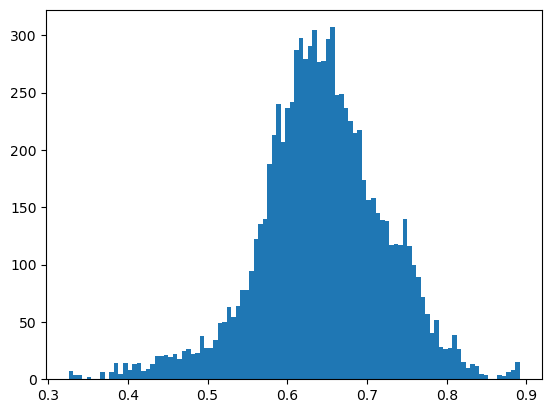

In [17]:
# plt.scatter(loc[:,1], loc[:,0], 2, np.concatenate([np.clip(data[:,p][:,None], 0, 1), np.zeros((len(data),2))], -1))
plt.hist(np.clip(data[:,p][:,None], 0, 1), bins=100);

In [34]:
# # region_cka.shape
# pairs
random_mean_cka = np.array([np.mean(region_cka[:,p]) for p in range(region_cka.shape[1])])

In [36]:
spatial_mean_cka = np.array([np.mean(region_cka[:,p]) for p in range(region_cka.shape[1])])

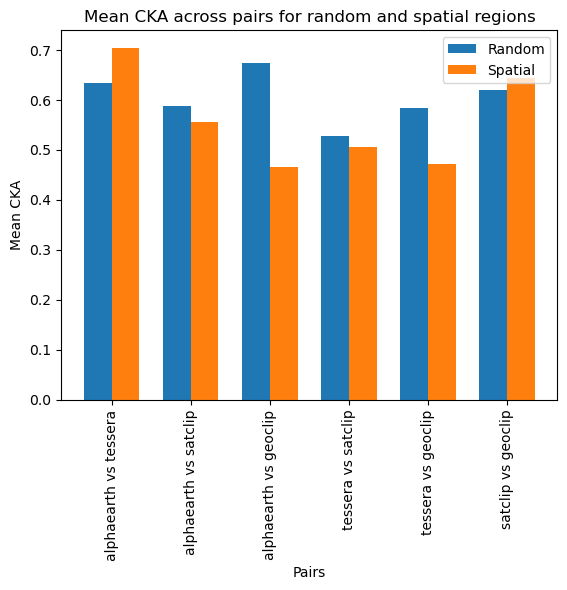

In [37]:
## Two bar plots in same ax for random and spatial mean cka across pairs

ax = plt.subplot(1,1,1)
bar_width = 0.35
index = np.arange(len(pairs))
plt.bar(index, random_mean_cka, bar_width, label='Random')
plt.bar(index + bar_width, spatial_mean_cka, bar_width, label='Spatial')
plt.xlabel('Pairs')
plt.ylabel('Mean CKA')
plt.title('Mean CKA across pairs for random and spatial regions')
plt.xticks(index + bar_width / 2, [f'{modalities[pair[0]]} vs {modalities[pair[1]]}' for pair in pairs], rotation=90)
plt.legend()

## Max distance:

In [101]:
from tqdm import tqdm
### CREATE OVERLAP MAPS ###

# Show representational overlap localised around patches:
# compute across a region of nearest neighbours for each patch
# Get longitude and latitude for all patches
locs = [gdf_points.set_index("id").loc[samp].reset_index(drop=True)[['lat', 'lon']].to_numpy() for samp in common_samples]
loc = locs[s]

# Create a approximate distance matrix between all points
# This is inaccurate but fast; geodesic would be better, but slow
coords_rad = np.radians(loc)
dist_matrix = haversine_distances(coords_rad) * 6371.0

# Select regions around points
# region_sizes = [50, 100, 250, 1000, 2500, 10000]
km_thresholds = [500, 800, 1000, 1500, 2000, 3000, 5000, 7500, 10000, 12500, 15000, 17500]
mean_cka = {}
sample_size = 25
pairs = [[i, j] for i in range(0,len(modalities)) for j in range(i+1,len(modalities))]
  
for km in km_thresholds:
  print(f'Calculating for region size {km}...')
  # regions = np.zeros((len(loc), sample_size), dtype=int)
  regions = {}
  for p, dist in enumerate(dist_matrix):
      # regions[p] = np.random.choice(np.argsort(dist)[:rs], sample_size, replace=False)
      ## randomly sample from all points within the km threshold:
      inds_within_km = np.where(dist <= km)[0]
      if len(inds_within_km) >= sample_size:
          regions[p] = np.random.choice(inds_within_km, sample_size, replace=False)
      else:
          regions[p] = np.random.choice(inds_within_km, sample_size, replace=True)

  # Calculate cka and rsa for each region
  # This time don't do feature-space cka, because there are more features than examples
  region_cka = np.zeros((len(loc), len(pairs)))
  # region_rsa = np.zeros((len(loc), len(pairs)))
  for r, region in tqdm(regions.items()):
    for p, pair in enumerate(pairs):
      region_cka[r, p] = cka(gram_linear(common_embeddings[pair[0]][s][region]), 
                            gram_linear(common_embeddings[pair[1]][s][region]))
      # region_rsa[r, p] = rsa(common_embeddings[pair[0]][s][region], 
      #                        common_embeddings[pair[1]][s][region])
  
  mean_cka[km] = np.array([np.mean(region_cka[:,p]) for p in range(region_cka.shape[1])])

Calculating for region size 500...


 58%|█████▊    | 5127/8901 [00:02<00:01, 2010.65it/s]/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_51062/455891937.py:113: RuntimeWarning: invalid value encountered in scalar divide
  return scaled_hsic / (normalization_x * normalization_y)
100%|██████████| 8901/8901 [00:04<00:00, 1995.24it/s]


Calculating for region size 800...


100%|██████████| 8901/8901 [00:04<00:00, 2168.44it/s]


Calculating for region size 1000...


...

100%|██████████| 8901/8901 [00:04<00:00, 1900.36it/s]


Calculating for region size 15000...


100%|██████████| 8901/8901 [00:04<00:00, 2078.90it/s]


Calculating for region size 17500...


100%|██████████| 8901/8901 [00:04<00:00, 1908.69it/s]


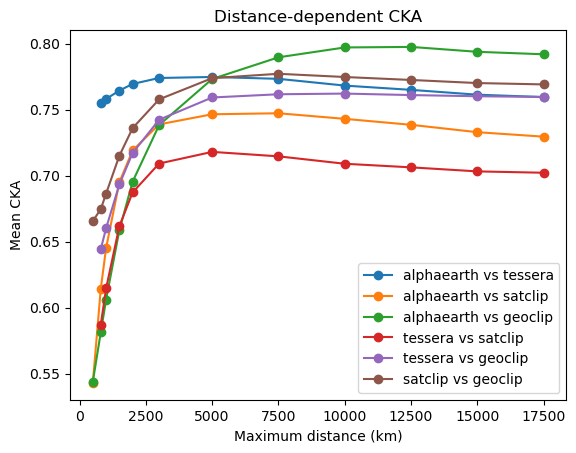

In [103]:


ax = plt.subplot(1,1,1)
for ind_pair in range(len(pairs)):

  mod_1 = modalities[pairs[ind_pair][0]]
  mod_2 = modalities[pairs[ind_pair][1]]

  data = np.array([mean_cka[rs][ind_pair] for rs in mean_cka.keys()])
  plt.plot(km_thresholds, data, label=f'{mod_1} vs {mod_2}', marker='o')

plt.xlabel('Maximum distance (km)')
plt.ylabel('Mean CKA')
plt.title(f'Distance-dependent CKA')
plt.legend()
plt.show()


## Mean distance:

In [18]:
from tqdm import tqdm
### CREATE OVERLAP MAPS ###

# Show representational overlap localised around patches:
# compute across a region of nearest neighbours for each patch
# Get longitude and latitude for all patches
locs = [gdf_points.set_index("id").loc[samp].reset_index(drop=True)[['lat', 'lon']].to_numpy() for samp in common_samples]
loc = locs[s]

# Create a approximate distance matrix between all points
# This is inaccurate but fast; geodesic would be better, but slow
coords_rad = np.radians(loc)
dist_matrix = haversine_distances(coords_rad) * 6371.0

# Select regions around points
km_thresholds = [300, 500, 800, 1000, 1500, 2000, 3000, 5000, 7500, 10000, 12500, 15000, 17500]
mean_cka = {}
sample_size = 25
pairs = [[i, j] for i in range(0,len(modalities)) for j in range(i+1,len(modalities))]
n_sample = 25
mean_cka = {}
for km in km_thresholds:
  print(f'Calculating for region size {km}...')
  
  ids_pairs_target = np.abs(dist_matrix - km) < 100
  region_0, region_1 = np.where(ids_pairs_target)
  ids_sample = np.random.choice(len(region_0), n_sample, replace=False)
  region_0, region_1 = region_0[ids_sample], region_1[ids_sample]
  region_cka = np.zeros(len(ids_pairs_target))
  # break
  for p, pair in enumerate(pairs):
    region_cka[p] = cka(gram_linear(common_embeddings[pair[0]][s][region_0]), 
                        gram_linear(common_embeddings[pair[1]][s][region_1]))
  mean_cka[km] = region_cka
#   mean_cka[km] = np.array([np.nanmean(region_cka[:,p]) for p in range(region_cka.shape[1])])


Calculating for region size 300...
Calculating for region size 500...
Calculating for region size 800...
Calculating for region size 1000...
Calculating for region size 1500...
Calculating for region size 2000...
Calculating for region size 3000...
Calculating for region size 5000...
Calculating for region size 7500...
Calculating for region size 10000...
Calculating for region size 12500...
Calculating for region size 15000...
Calculating for region size 17500...


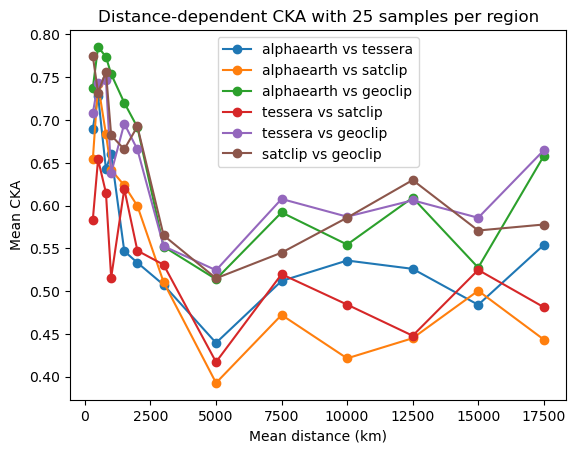

In [19]:


ax = plt.subplot(1,1,1)
for ind_pair in range(len(pairs)):

  mod_1 = modalities[pairs[ind_pair][0]]
  mod_2 = modalities[pairs[ind_pair][1]]

  data = np.array([mean_cka[rs][ind_pair] for rs in mean_cka.keys()])
  plt.plot(km_thresholds, data, label=f'{mod_1} vs {mod_2}', marker='o')

plt.xlabel('Mean distance (km)')
plt.ylabel('Mean CKA')
plt.title(f'Distance-dependent CKA with {sample_size} samples per region')
plt.legend()
plt.show()
